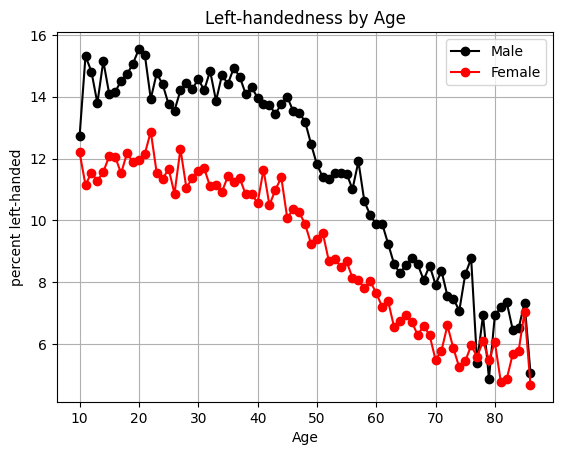

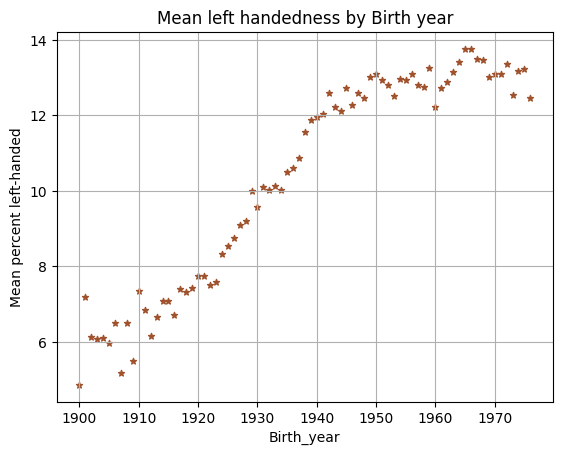

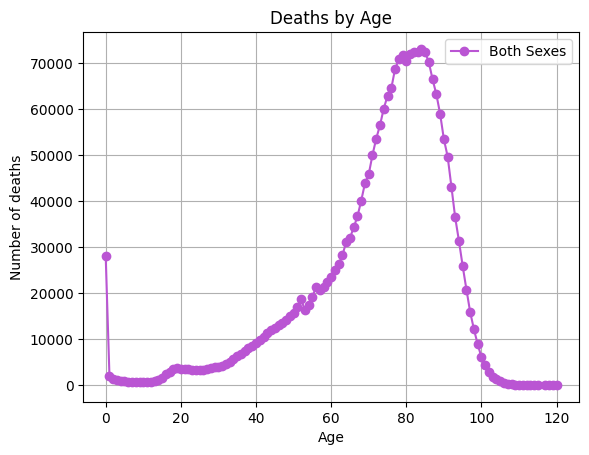

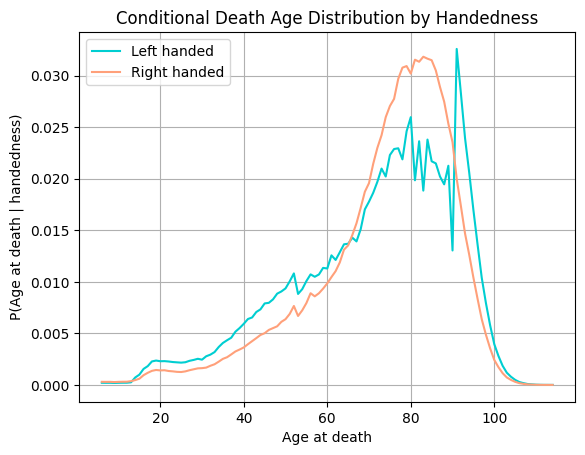

Average age of Left-handed people at death: 71.37 years.
Average age of Right-handed people at death: 73.59 years.
Difference: 2.22 years.
In 2018
Average age of Left-handed people at death: 72.96 years.
Average age of Right-handed people at death: 73.46 years.
Difference: 0.5 years.


In [1]:
# Task 1: Load handedness data and create scatter plot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data_url_1 = "https://gist.githubusercontent.com/mbonsma/8da0990b71ba9a09f7de395574e54df1/raw/aec88b30af87fad8d45da7e774223f91dad09e88/lh_data.csv"
lefthanded_data = pd.read_csv(data_url_1)

#plot Male and Female vs. Age
lefthanded_data.plot(x = 'Age', y = ['Male','Female'], marker= 'o',title= 'Left-handedness by Age',kind='line', grid= True, color=['black','red'])
plt.ylabel('percent left-handed')
plt.show()

# Task 2: Add Birth_year and Mean_lh columns, Plot Mean_lh VS Birth_year
lefthanded_data['Birth_year'] = 1986 - lefthanded_data['Age']
lefthanded_data['Mean_lh'] = lefthanded_data[['Male', 'Female']].mean(axis= 1)

lefthanded_data.plot(x= 'Birth_year', y='Mean_lh', kind='scatter',color= 'sienna',marker='*', title= "Mean left handedness by Birth year", grid=True)
plt.ylabel("Mean percent left-handed")
plt.show()

# Task 3: Create function for P(LH | A)
def P_lh_given_A(ages_of_death, study_year=1990):
  early_1900s_rate = lefthanded_data['Mean_lh'].iloc[-10:].mean()
  late_1900s_rate = lefthanded_data['Mean_lh'].iloc[:10].mean()

  birth_years = study_year - ages_of_death

  middle_rates = lefthanded_data.set_index('Birth_year').reindex(birth_years)['Mean_lh'].fillna(0)

  youngest_age = study_year - 1986 + 10
  oldest_age = study_year - 1986 + 86

  P_return = np.zeros(ages_of_death.shape)
  P_return[ages_of_death > oldest_age] = late_1900s_rate/100
  P_return[ages_of_death < youngest_age] = early_1900s_rate/100
  in_range = np.logical_and((ages_of_death <= oldest_age),(ages_of_death >= youngest_age))
  P_return[in_range] = middle_rates[in_range].values/100

  return P_return

# Task 4. When do people normally die?
data_url_2 = "https://gist.githubusercontent.com/mbonsma/2f4076aab6820ca1807f4e29f75f18ec/raw/62f3ec07514c7e31f5979beeca86f19991540796/cdc_vs00199_table310.tsv"
death_distribution_data = pd.read_csv(data_url_2, sep= '\t', skiprows= [1])

# Drop NaNs from 'Both Sexes'
death_distribution_data = death_distribution_data.dropna(subset= ['Both Sexes'])

#Fix: Convert 'Age' to numeric and frop non-numeric
death_distribution_data['Age'] = pd.to_numeric(death_distribution_data['Age'], errors= 'coerce')
death_distribution_data = death_distribution_data.dropna(subset= ['Age'])
death_distribution_data['Age'] = death_distribution_data['Age'].astype(int)

# Plot
death_distribution_data.plot(x='Age', y='Both Sexes',color= 'mediumorchid',kind= 'line',grid=True, marker='o', title="Deaths by Age")
plt.ylabel("Number of deaths")
plt.show()

# Take 5: function to compare p(LH)
def P_lh(death_distribution_data, study_year= 1990):
  P_list = P_lh_given_A(death_distribution_data['Age'].values, study_year)* death_distribution_data['Both Sexes']
  P = np.nansum(P_list)
  return P/np.nansum(death_distribution_data['Both Sexes'])

# Task 6: Function to compute P(A | LH)
def P_A_given_lh(ages_of_death, death_distribution_data, study_year = 1990):
  P_A= death_distribution_data['Both Sexes'] / np.nansum(death_distribution_data['Both Sexes'])
  P_left = P_lh(death_distribution_data, study_year)
  P_lh_A= P_lh_given_A(ages_of_death, study_year)
  return P_lh_A*P_A.values / P_left

# Task 7: Function to compute P(A | RH)
def P_A_given_rh(ages_of_death, death_distribution_data, study_year = 1990):
  P_A = death_distribution_data['Both Sexes'] / np.nansum(death_distribution_data['Both Sexes'])
  P_right = 1 - P_lh(death_distribution_data, study_year)
  P_rh_A = 1 - P_lh_given_A(ages_of_death, study_year)
  return P_rh_A * P_A.values / P_right

# Task 8: Plot conditionsl probabilities for LH and RH
ages = np.arange(6,115,1)
filtered_death_data = death_distribution_data[death_distribution_data['Age'].between(6,114)].copy()

left_handed_probability = P_A_given_lh(ages, filtered_death_data)
right_handed_probability = P_A_given_rh(ages, filtered_death_data)

plt.plot(ages, left_handed_probability, label ="Left handed", color= 'darkturquoise')
plt.plot(ages, right_handed_probability, label = 'Right handed', color= 'lightsalmon')
plt.xlabel("Age at death")
plt.ylabel('P(Age at death | handedness)')
plt.title("Conditional Death Age Distribution by Handedness")
plt.grid()
plt.legend()
plt.show()

# Task 9: Compute and print average ages at death
average_lh_age = np.nansum(ages* left_handed_probability)
average_rh_age = np.nansum(ages* right_handed_probability)

print("Average age of Left-handed people at death:", round(average_lh_age,2),"years.")
print("Average age of Right-handed people at death:", round(average_rh_age,2), "years.")

print("Difference:", round(average_rh_age - average_lh_age, 2), "years.")

# Task 10: Redo for study_year = 2018
left_handed_probability_2018 = P_A_given_lh(ages, filtered_death_data, study_year= 2018)
right_handed_probability_2018 = P_A_given_rh(ages, filtered_death_data, study_year= 2018)

average_lh_age_2018 = np.nansum(ages * left_handed_probability_2018)
average_rh_age_2018 = np.nansum(ages * right_handed_probability_2018)

print("In 2018")
print("Average age of Left-handed people at death:", round(average_lh_age_2018,2),"years.")
print("Average age of Right-handed people at death:", round(average_rh_age_2018,2),"years.")
print("Difference:", round(average_rh_age_2018 - average_lh_age_2018, 2),"years.")